In [58]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from scipy.stats import f_oneway, f
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import chi2_contingency

In [2]:
df = pd.read_csv('Data/train.csv')
df 

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


[]

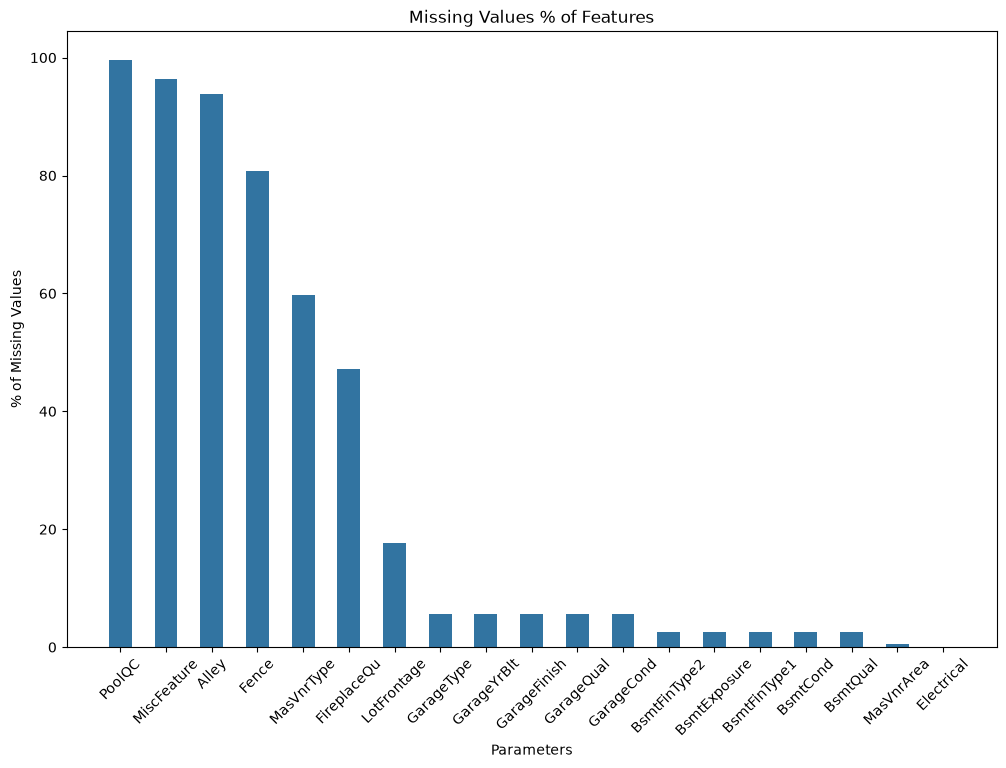

In [3]:
percentage_nan = (df[df.columns].isna().sum()) / len(df) *100
perc_nan = percentage_nan[percentage_nan.values>0].sort_values(ascending = False)
plt.figure(figsize= (12,8))
plt.xlabel("Parameters")
plt.ylabel("% of Missing Values")
plt.title("Missing Values % of Features")
plt.xticks(rotation = 45)
sns.barplot(x = perc_nan.index , y=perc_nan.values,width=0.5) 
plt.plot()

In [31]:
def categorical_missing_analysis(df, categorical_col, target = 'SalePrice', alpha=0.05):

    print(df[categorical_col].value_counts())

    plt.figure(figsize=(8,6))
    sns.boxplot(data=df,x=f'{categorical_col}',y="SalePrice")
    plt.show()

    
    # ANOVA TEST
    groups = [
        group[target].values
        for _, group in df.groupby(categorical_col)]

    f_stat, p_value = f_oneway(*groups)

    k = df[categorical_col].nunique()
    N = len(df)

    df_between = k - 1
    df_within = N - k

    f_critical = f.ppf(1 - alpha, df_between, df_within)

    print(f"\nFeature : {categorical_col}")
    print("-"*40)
    print(f"F Statistic : {f_stat:.4f}")
    print(f"P Value     : {p_value:.6f}")
    print(f"Critical F  : {f_critical:.4f}")

    print("\nDecision:")

    if p_value < alpha:
        print("✓ Reject H₀")
        print("There is a statistically significant difference in mean SalePrice among the categories.")
    else:
        print("✗ Fail to reject H₀")
        print("No statistically significant difference in mean SalePrice among the categories.")

    # TUKEY'S HSD TEST (IF SUBCATEGORIES CAN BE MERGED)
    tukey = pairwise_tukeyhsd(
        endog=df["SalePrice"],
        groups=df[categorical_col],
        alpha=0.05)
    print(tukey)

In [7]:
df['PoolQC'] = df['PoolQC'].fillna("No")

PoolQC
No    1453
Gd       3
Ex       2
Fa       2
Name: count, dtype: int64


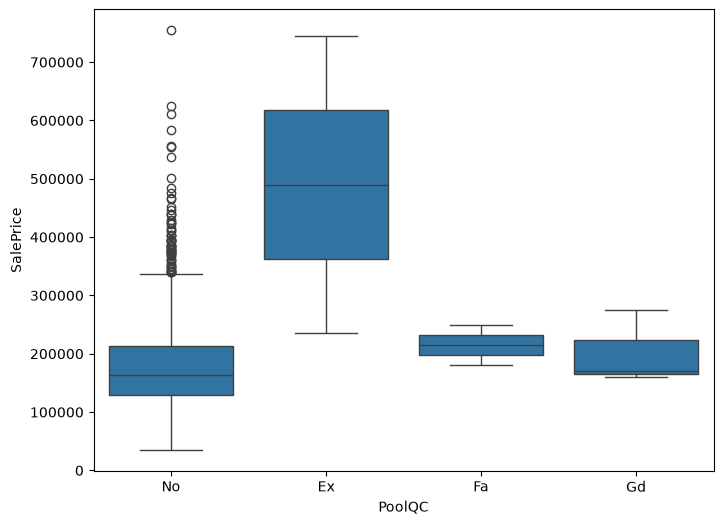


Feature : PoolQC
----------------------------------------
F Statistic : 10.5099
P Value     : 0.000001
Critical F  : 2.6110

Decision:
✓ Reject H₀
There is a statistically significant difference in mean SalePrice among the categories.


In [8]:
categorical_missing_analysis(df=df,categorical_col='PoolQC')

In [9]:
df['MiscFeature'] = df['MiscFeature'].fillna("No")

MiscFeature
No      1406
Shed      49
Gar2       2
Othr       2
TenC       1
Name: count, dtype: int64


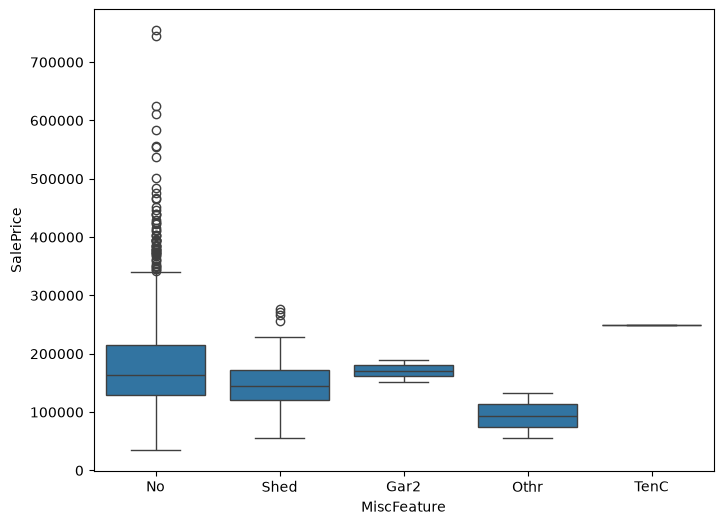


Feature : MiscFeature
----------------------------------------
F Statistic : 2.5936
P Value     : 0.035004
Critical F  : 2.3780

Decision:
✓ Reject H₀
There is a statistically significant difference in mean SalePrice among the categories.


In [12]:
categorical_missing_analysis(df=df,categorical_col='MiscFeature')

In [13]:
df['Alley'] = df['Alley'].fillna("No")

Alley
No      1369
Grvl      50
Pave      41
Name: count, dtype: int64


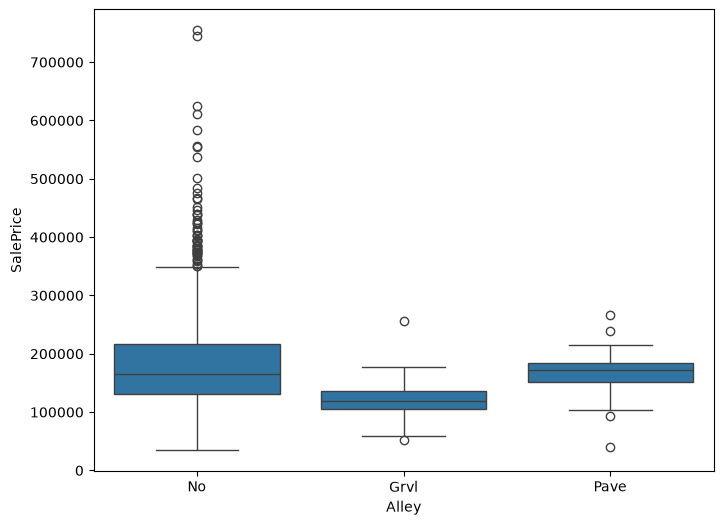


Feature : Alley
----------------------------------------
F Statistic : 15.1766
P Value     : 0.000000
Critical F  : 3.0019

Decision:
✓ Reject H₀
There is a statistically significant difference in mean SalePrice among the categories.


In [14]:
categorical_missing_analysis(df=df,categorical_col='Alley')

In [15]:
df['Fence'] = df['Fence'].fillna("No")

Fence
No       1179
MnPrv     157
GdPrv      59
GdWo       54
MnWw       11
Name: count, dtype: int64


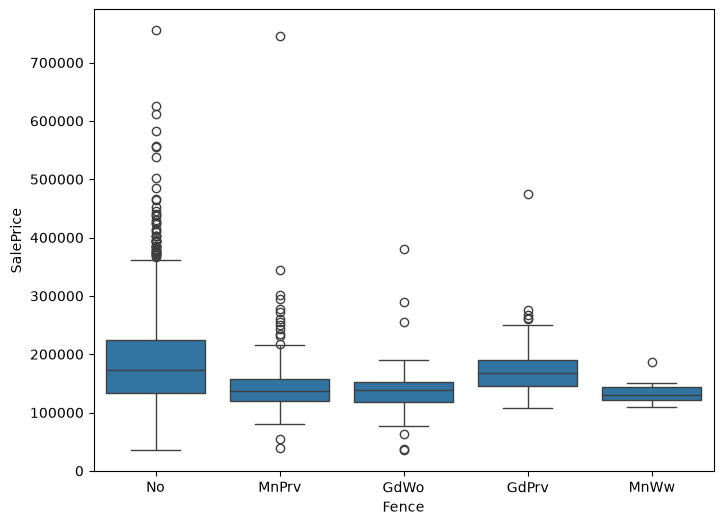


Feature : Fence
----------------------------------------
F Statistic : 13.4333
P Value     : 0.000000
Critical F  : 2.3780

Decision:
✓ Reject H₀
There is a statistically significant difference in mean SalePrice among the categories.
      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
group1 group2   meandiff  p-adj     lower        upper    reject
----------------------------------------------------------------
 GdPrv   GdWo -38548.1428 0.0673  -78731.3123   1635.0266  False
 GdPrv  MnPrv -30176.3685 0.0847  -62758.4553   2405.7184  False
 GdPrv   MnWw  -44641.094 0.4097 -114714.7093  25432.5213  False
 GdPrv     No   8669.3804 0.9208  -19795.2315  37133.9923  False
  GdWo  MnPrv   8371.7744 0.9609  -25288.8661  42032.4148  False
  GdWo   MnWw  -6092.9512 0.9993  -76674.5202  64488.6179  False
  GdWo     No  47217.5232 0.0001   17524.4185  76910.6278   True
 MnPrv   MnWw -14464.7255 0.9761  -81012.9273  52083.4763  False
 MnPrv     No  38845.7488    0.0   20718.8148  569

In [29]:
categorical_missing_analysis(df=df,categorical_col='Fence')

In [17]:
perc_nan

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtFinType1     2.534247
BsmtCond         2.534247
BsmtQual         2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64

In [20]:
df['MasVnrType'] = df['MasVnrType'].fillna("No")

MasVnrType
No         872
BrkFace    445
Stone      128
BrkCmn      15
Name: count, dtype: int64


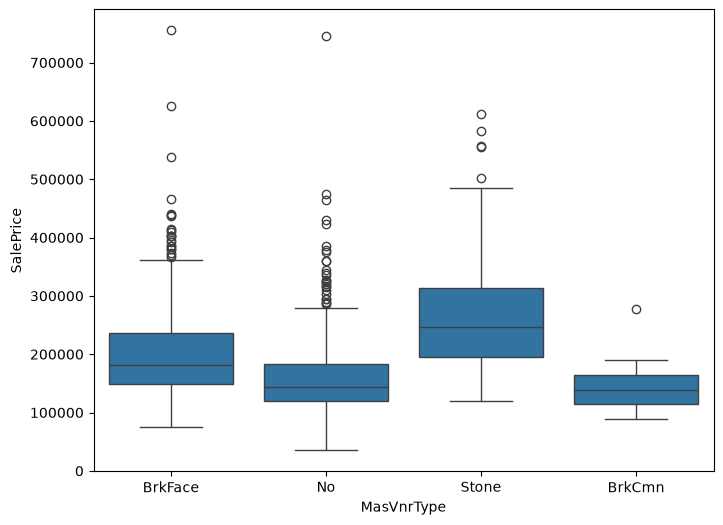


Feature : MasVnrType
----------------------------------------
F Statistic : 108.9113
P Value     : 0.000000
Critical F  : 2.6110

Decision:
✓ Reject H₀
There is a statistically significant difference in mean SalePrice among the categories.
       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
 group1  group2   meandiff  p-adj     lower       upper    reject
-----------------------------------------------------------------
 BrkCmn BrkFace  58373.8052 0.0108   9849.2388 106898.3717   True
 BrkCmn      No  10640.1765 0.9414 -37495.4159  58775.7688  False
 BrkCmn   Stone 119265.5583    0.0  68819.6685 169711.4482   True
BrkFace      No -47733.6288    0.0 -58502.3224 -36964.9351   True
BrkFace   Stone  60891.7531    0.0  42352.1384  79431.3678   True
     No   Stone 108625.3819    0.0  91129.1246 126121.6391   True
-----------------------------------------------------------------


In [32]:
categorical_missing_analysis(df=df,categorical_col='MasVnrType')

In [24]:
df['FireplaceQu'] = df['FireplaceQu'].fillna("No")

FireplaceQu
No    690
Gd    380
TA    313
Fa     33
Ex     24
Po     20
Name: count, dtype: int64


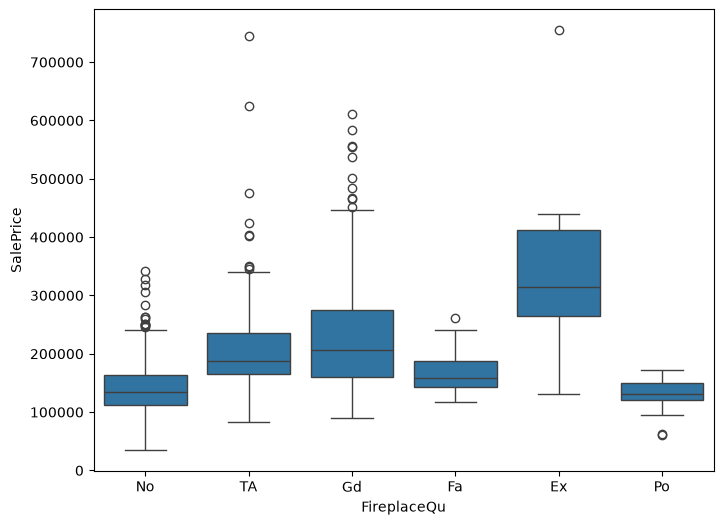


Feature : FireplaceQu
----------------------------------------
F Statistic : 121.0751
P Value     : 0.000000
Critical F  : 2.2203

Decision:
✓ Reject H₀
There is a statistically significant difference in mean SalePrice among the categories.
       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
group1 group2   meandiff   p-adj     lower        upper     reject
------------------------------------------------------------------
    Ex     Fa -170414.0152    0.0 -221602.0065 -119226.0238   True
    Ex     Gd -111361.0842    0.0 -151520.4193  -71201.7491   True
    Ex     No -196381.0174    0.0 -236000.8093 -156761.2255   True
    Ex     Po   -207948.35    0.0 -265717.8981 -150178.8019   True
    Ex     TA -131989.0112    0.0 -172402.8785  -91575.1439   True
    Fa     Gd   59052.9309    0.0   24425.5609    93680.301   True
    Fa     No  -25967.0022  0.248  -59967.1562    8033.1517  False
    Fa     Po  -37534.3348 0.3538  -91604.6894   16536.0197  False
    Fa     TA    3842

In [33]:
categorical_missing_analysis(df=df,categorical_col='FireplaceQu')

In [41]:
def numerical_missing_analysis(num_col, df=df, target='SalePrice', alpha=0.05):

    fig, axes = plt.subplots(3, 1, figsize=(8, 12))

    # Scatter Plot
    sns.scatterplot(data=df,x=target,y=num_col,ax=axes[0])
    axes[0].set_title(f"{target} vs {num_col}")

    # Histogram
    skewness = df[num_col].skew()
    sns.histplot(data=df,x=num_col,kde=True,ax=axes[1])

    axes[1].set_title(f"Distribution of {num_col}\nSkewness = {skewness:.3f}")

    # Box Plot
    sns.boxplot(data=df,x=num_col,y=target,ax=axes[2])
    axes[2].set_title(f"{num_col} vs {target}")

    plt.tight_layout()
    plt.show()

    missing_count = df[num_col].isnull().sum()
    missing_percent = df[num_col].isnull().mean() * 100

    print(f"Column           : {num_col}")
    print(f"Missing Values   : {missing_count}")
    print(f"Missing Percent  : {missing_percent:.2f}%")
    print(f"Skewness         : {skewness:.3f}")
    print(f"Median           : {df[num_col].median():.2f}")
    print(f"Mean             : {df[num_col].mean():.2f}")

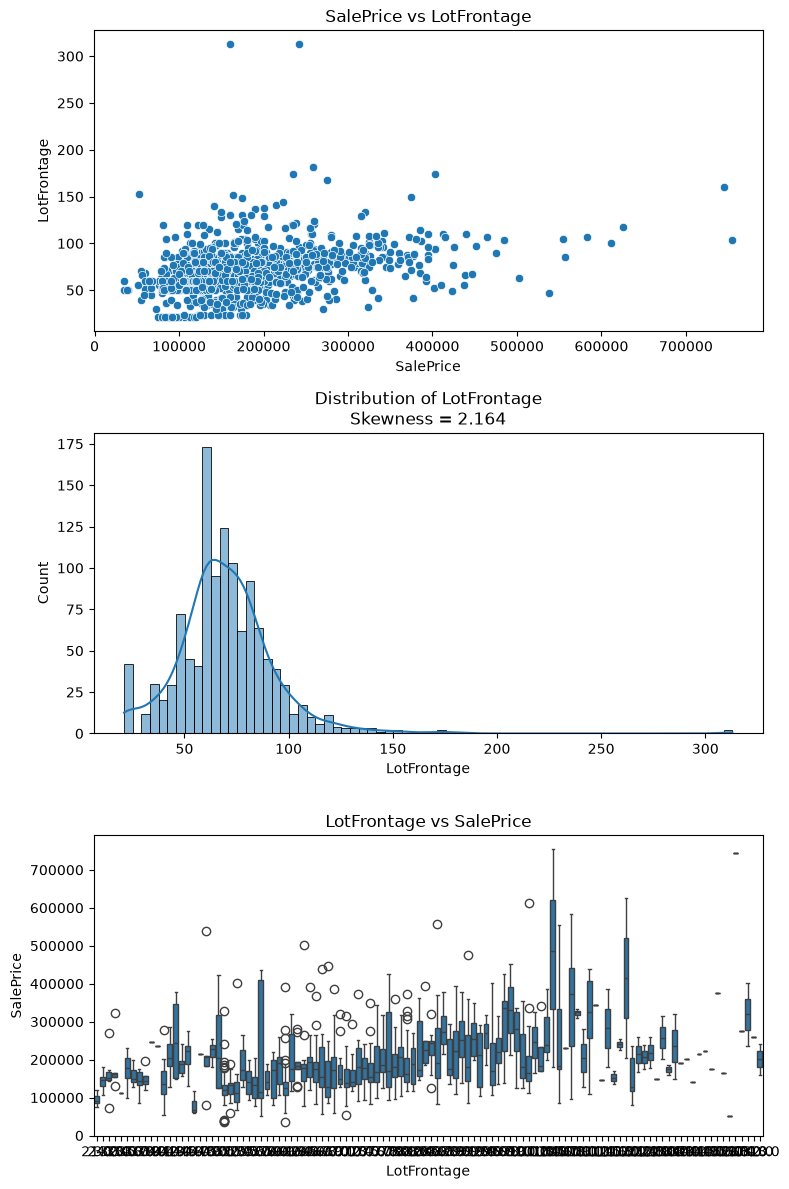

Column           : LotFrontage
Missing Values   : 259
Missing Percent  : 17.74%
Skewness         : 2.164
Median           : 69.00
Mean             : 70.05


In [42]:
numerical_missing_analysis(num_col='LotFrontage')

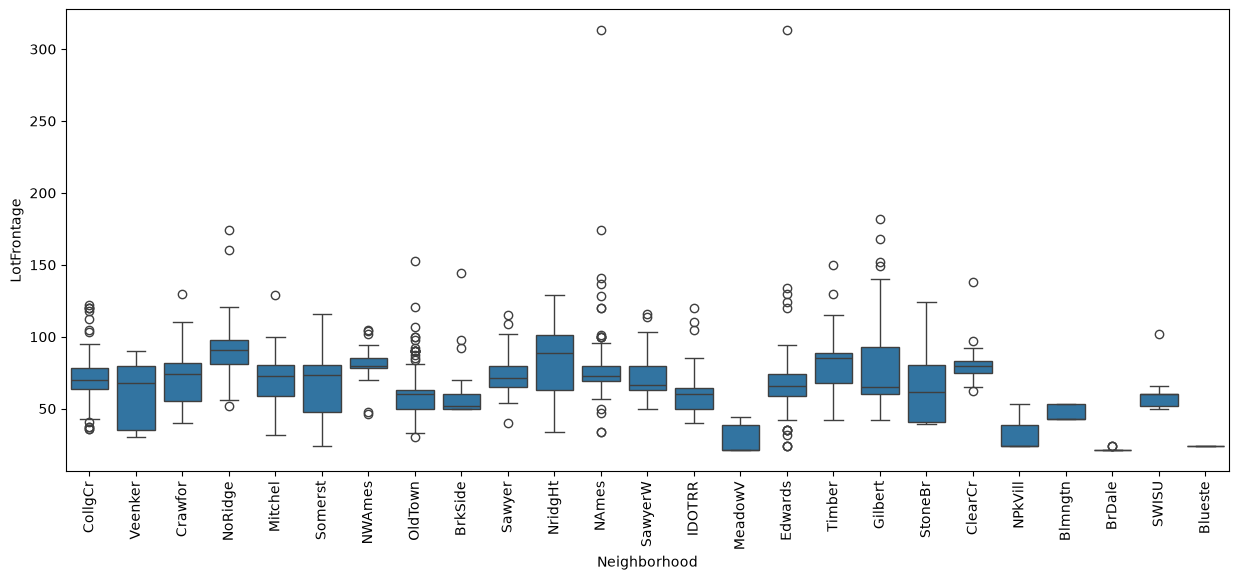

In [43]:
plt.figure(figsize=(15,6))

sns.boxplot(
    data=df,
    x="Neighborhood",
    y="LotFrontage"
)

plt.xticks(rotation=90)
plt.show()

In [45]:
perc_nan.index

Index(['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu',
       'LotFrontage', 'GarageType', 'GarageYrBlt', 'GarageFinish',
       'GarageQual', 'GarageCond', 'BsmtFinType2', 'BsmtExposure',
       'BsmtFinType1', 'BsmtCond', 'BsmtQual', 'MasVnrArea', 'Electrical'],
      dtype='str')

In [47]:
df[perc_nan.index].info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PoolQC        1460 non-null   str    
 1   MiscFeature   1460 non-null   str    
 2   Alley         1460 non-null   str    
 3   Fence         1460 non-null   str    
 4   MasVnrType    1460 non-null   str    
 5   FireplaceQu   1460 non-null   str    
 6   LotFrontage   1201 non-null   float64
 7   GarageType    1379 non-null   str    
 8   GarageYrBlt   1379 non-null   float64
 9   GarageFinish  1379 non-null   str    
 10  GarageQual    1379 non-null   str    
 11  GarageCond    1379 non-null   str    
 12  BsmtFinType2  1422 non-null   str    
 13  BsmtExposure  1422 non-null   str    
 14  BsmtFinType1  1423 non-null   str    
 15  BsmtCond      1423 non-null   str    
 16  BsmtQual      1423 non-null   str    
 17  MasVnrArea    1452 non-null   float64
 18  Electrical    1459 non-null   str    
d

GarageType
Attchd     870
Detchd     387
BuiltIn     88
No          81
Basment     19
CarPort      9
2Types       6
Name: count, dtype: int64


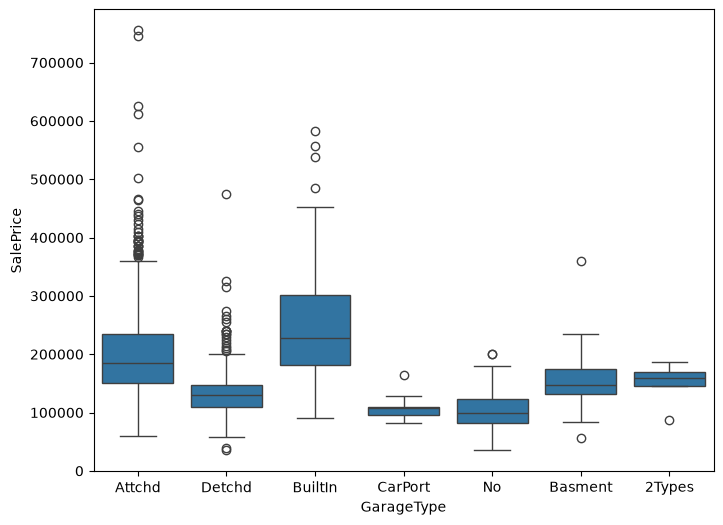


Feature : GarageType
----------------------------------------
F Statistic : 80.3800
P Value     : 0.000000
Critical F  : 2.1048

Decision:
✓ Reject H₀
There is a statistically significant difference in mean SalePrice among the categories.
        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
 group1  group2   meandiff   p-adj     lower        upper     reject
--------------------------------------------------------------------
 2Types  Attchd    51609.323 0.5302  -31818.4455  135037.0914  False
 2Types Basment    9287.3509    1.0   -86082.566  104657.2678  False
 2Types BuiltIn  103468.4053 0.0071   17539.2009  189397.6098   True
 2Types CarPort  -41321.2222 0.9168 -148656.5224   66014.0779  False
 2Types  Detchd  -17192.1705 0.9966 -100975.7659   66591.4248  False
 2Types      No  -47966.0494 0.6539 -134131.9273   38199.8285  False
 Attchd Basment  -42321.9721 0.1133  -89550.9209    4906.9767  False
 Attchd BuiltIn   51859.0823    0.0   29077.9337    74640.231   True
 

In [52]:
df['GarageType'] = df['GarageType'].fillna("No")
categorical_missing_analysis(df=df,categorical_col='GarageType')

GarageFinish
Unf    605
RFn    422
Fin    352
No      81
Name: count, dtype: int64


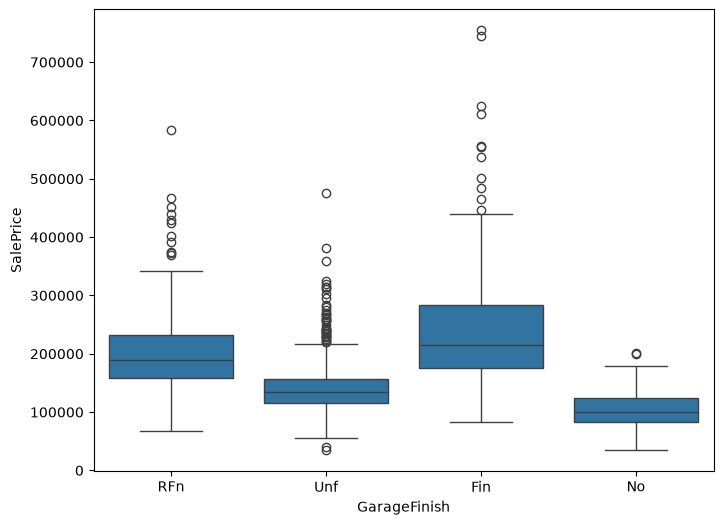


Feature : GarageFinish
----------------------------------------
F Statistic : 213.8670
P Value     : 0.000000
Critical F  : 2.6110

Decision:
✓ Reject H₀
There is a statistically significant difference in mean SalePrice among the categories.
       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
group1 group2   meandiff   p-adj    lower        upper     reject
-----------------------------------------------------------------
   Fin     No -136735.4064   0.0 -157735.4552 -115735.3576   True
   Fin    RFn  -37983.8207   0.0  -50284.6139  -25683.0274   True
   Fin    Unf  -97896.2672   0.0 -109319.7136  -86472.8208   True
    No    RFn   98751.5857   0.0   78079.9209  119423.2505   True
    No    Unf   38839.1392   0.0   18677.2113   59001.0671   True
   RFn    Unf  -59912.4465   0.0  -70720.3512  -49104.5419   True
-----------------------------------------------------------------


In [53]:
df['GarageFinish'] = df['GarageFinish'].fillna("No")
categorical_missing_analysis(df=df,categorical_col='GarageFinish')

GarageQual
TA    1311
No      81
Fa      48
Gd      14
Ex       3
Po       3
Name: count, dtype: int64


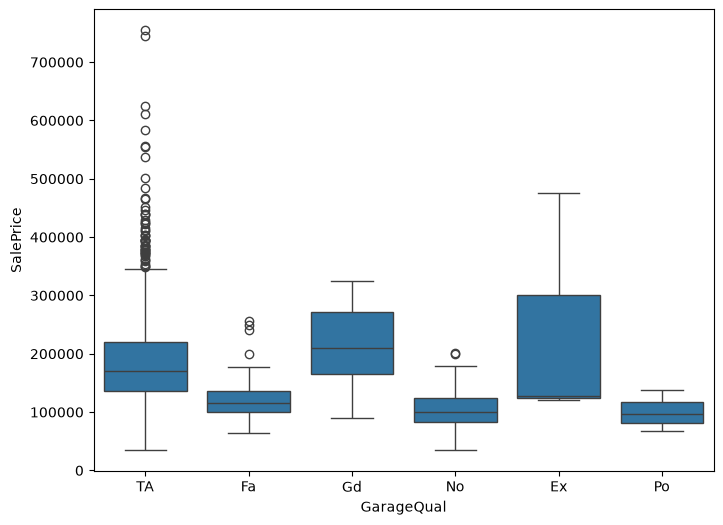


Feature : GarageQual
----------------------------------------
F Statistic : 25.7761
P Value     : 0.000000
Critical F  : 2.2203

Decision:
✓ Reject H₀
There is a statistically significant difference in mean SalePrice among the categories.
       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
group1 group2   meandiff   p-adj     lower        upper    reject
-----------------------------------------------------------------
    Ex     Fa -117426.6458  0.101 -246947.8325  12094.5408  False
    Ex     Gd  -25139.2857 0.9955 -163603.2585 113324.6871  False
    Ex     No  -137682.716 0.0264 -265642.4943  -9722.9377   True
    Ex     Po -140833.3333 0.2107 -318534.9354  36868.2687  False
    Ex     TA   -53510.164 0.8303 -179307.8586  72287.5306  False
    Fa     Gd   92287.3601  0.001   26180.2487 158394.4716   True
    Fa     No  -20256.0702 0.6911  -59899.2699  19387.1294  False
    Fa     Po  -23406.6875 0.9956 -152927.8742 106114.4992  False
    Fa     TA   63916.4818    0.0 

In [54]:
df['GarageQual'] = df['GarageQual'].fillna("No")
categorical_missing_analysis(df=df,categorical_col='GarageQual')

GarageCond
TA    1326
No      81
Fa      35
Gd       9
Po       7
Ex       2
Name: count, dtype: int64


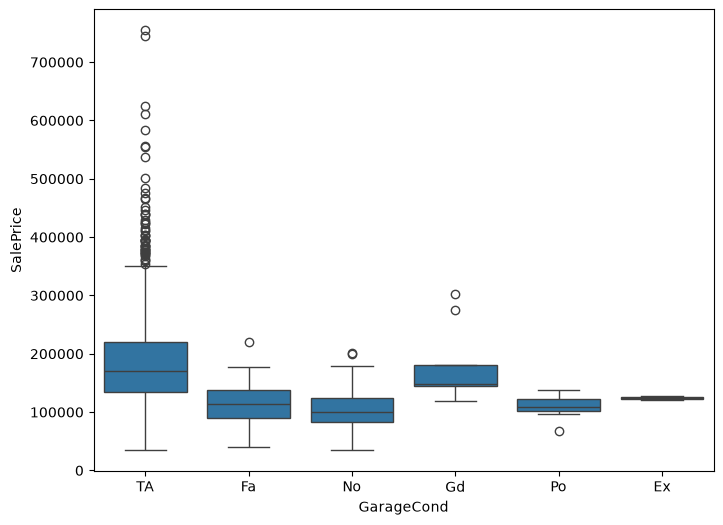


Feature : GarageCond
----------------------------------------
F Statistic : 25.7502
P Value     : 0.000000
Critical F  : 2.2203

Decision:
✓ Reject H₀
There is a statistically significant difference in mean SalePrice among the categories.
      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
group1 group2   meandiff  p-adj     lower        upper    reject
----------------------------------------------------------------
    Ex     Fa  -9345.9714    1.0 -167582.4497 148890.5068  False
    Ex     Gd     55930.0 0.9366 -114213.3019 226073.3019  False
    Ex     No  -20682.716  0.999 -176471.5424 135106.1103  False
    Ex     Po    -15500.0 0.9999 -190006.6588 159006.6588  False
    Ex     TA  63885.7353 0.8448  -90130.6918 217902.1624  False
    Fa     Gd  65275.9714 0.1988  -16068.0854 146620.0283  False
    Fa     No -11336.7446 0.9776  -55362.5419  32689.0527  False
    Fa     Po  -6154.0286    1.0  -96268.8797  83960.8226  False
    Fa     TA  73231.7067    0.0    35960.106

In [56]:
df['GarageCond'] = df['GarageCond'].fillna("No")
categorical_missing_analysis(df=df,categorical_col='GarageCond')

In [59]:
def cramers_v(df, col1, col2):

    # Remove missing values
    temp = df[[col1, col2]].dropna()

    # Contingency table
    contingency_table = pd.crosstab(temp[col1], temp[col2])

    # Chi-square test
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    # Sample size
    n = contingency_table.values.sum()

    # Minimum dimension
    r, c = contingency_table.shape
    min_dim = min(r - 1, c - 1)

    # Cramer's V
    cramers_v = np.sqrt(chi2 / (n * min_dim))

    print(f"\nFeature Comparison : {col1} vs {col2}")
    print("-" * 50)
    print(f"Chi-square Statistic : {chi2:.4f}")
    print(f"P-value              : {p_value:.6f}")
    print(f"Cramer's V           : {cramers_v:.4f}")

    print("\nInterpretation")

    if cramers_v < 0.10:
        strength = "Negligible Association"
    elif cramers_v < 0.30:
        strength = "Weak Association"
    elif cramers_v < 0.50:
        strength = "Moderate Association"
    elif cramers_v < 0.70:
        strength = "Strong Association"
    else:
        strength = "Very Strong Association"

    print(f"Association Strength : {strength}")

    if p_value < 0.05:
        print("✓ Association is statistically significant.")
    else:
        print("✗ Association is NOT statistically significant.")

    return cramers_v

In [60]:
cramers_v(df, "GarageQual", "GarageCond")


Feature Comparison : GarageQual vs GarageCond
--------------------------------------------------
Chi-square Statistic : 3633.0622
P-value              : 0.000000
Cramer's V           : 0.7055

Interpretation
Association Strength : Very Strong Association
✓ Association is statistically significant.


np.float64(0.7054642145501732)

In [61]:
(
    df["GarageQual"] == df["GarageCond"]
).mean()

np.float64(0.9595890410958904)

In [62]:
pd.crosstab(df["GarageQual"], df["GarageCond"])

GarageCond,Ex,Fa,Gd,No,Po,TA
GarageQual,,,,,,
Ex,2,0,0,0,0,1
Fa,0,20,0,0,4,24
Gd,0,0,4,0,0,10
No,0,0,0,81,0,0
Po,0,0,0,0,3,0
TA,0,15,5,0,0,1291


In [63]:
df[perc_nan.index].info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PoolQC        1460 non-null   str    
 1   MiscFeature   1460 non-null   str    
 2   Alley         1460 non-null   str    
 3   Fence         1460 non-null   str    
 4   MasVnrType    1460 non-null   str    
 5   FireplaceQu   1460 non-null   str    
 6   LotFrontage   1201 non-null   float64
 7   GarageType    1460 non-null   str    
 8   GarageYrBlt   1379 non-null   float64
 9   GarageFinish  1460 non-null   str    
 10  GarageQual    1460 non-null   str    
 11  GarageCond    1460 non-null   str    
 12  BsmtFinType2  1422 non-null   str    
 13  BsmtExposure  1422 non-null   str    
 14  BsmtFinType1  1423 non-null   str    
 15  BsmtCond      1423 non-null   str    
 16  BsmtQual      1423 non-null   str    
 17  MasVnrArea    1452 non-null   float64
 18  Electrical    1459 non-null   str    
d

BsmtFinType1
Unf    430
GLQ    418
ALQ    220
BLQ    148
Rec    133
LwQ     74
No      37
Name: count, dtype: int64


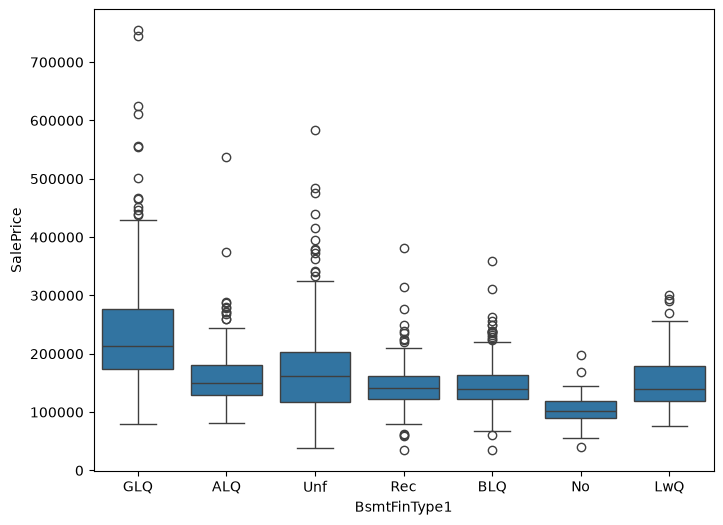


Feature : BsmtFinType1
----------------------------------------
F Statistic : 64.6882
P Value     : 0.000000
Critical F  : 2.1048

Decision:
✓ Reject H₀
There is a statistically significant difference in mean SalePrice among the categories.
       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
group1 group2   meandiff   p-adj     lower        upper    reject
-----------------------------------------------------------------
   ALQ    BLQ  -12079.4128 0.6781   -34276.976  10118.1505  False
   ALQ    GLQ   73840.6519    0.0   56449.2557  91232.0481   True
   ALQ    LwQ   -9720.3655 0.9489  -37779.2277  18338.4967  False
   ALQ     No  -55920.1763 0.0002  -93020.5215 -18819.8311   True
   ALQ    Rec  -14683.8201  0.487  -37617.5019   8249.8618  False
   ALQ    Unf    9097.5086  0.713   -8210.0058  26405.0229  False
   BLQ    GLQ   85920.0647    0.0    65948.467 105891.6623   True
   BLQ    LwQ    2359.0473    1.0  -27368.1086  32086.2032  False
   BLQ     No  -43840.7635 0.013

In [64]:
df['BsmtFinType1'] = df['BsmtFinType1'].fillna("No")
categorical_missing_analysis(df=df,categorical_col='BsmtFinType1')

BsmtFinType2
Unf    1256
Rec      54
LwQ      46
No       38
BLQ      33
ALQ      19
GLQ      14
Name: count, dtype: int64


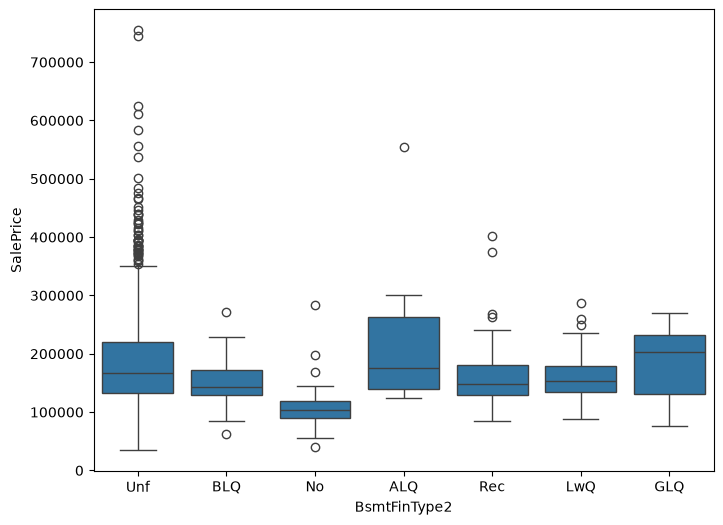


Feature : BsmtFinType2
----------------------------------------
F Statistic : 7.5654
P Value     : 0.000000
Critical F  : 2.1048

Decision:
✓ Reject H₀
There is a statistically significant difference in mean SalePrice among the categories.
      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
group1 group2   meandiff  p-adj     lower        upper    reject
----------------------------------------------------------------
   ALQ    BLQ -58841.1053 0.1247 -125494.2836   7812.0731  False
   ALQ    GLQ -28959.9624 0.9424 -110480.8902  52560.9654  False
   ALQ    LwQ -45577.9748 0.3343 -108696.0758  17540.1262  False
   ALQ     No -99595.8684 0.0001 -164627.0719 -34564.6649   True
   ALQ    Rec -45024.9756  0.322 -106761.2919  16711.3406  False
   ALQ    Unf  -25247.415 0.8056   -78745.278   28250.448  False
   BLQ    GLQ  29881.1429 0.8962  -43940.0236 103702.3093  False
   BLQ    LwQ  13263.1304 0.9899  -39536.4683  66062.7292  False
   BLQ     No -40754.7632 0.3043  -95827.082

In [65]:
df['BsmtFinType2'] = df['BsmtFinType2'].fillna("No")
categorical_missing_analysis(df=df,categorical_col='BsmtFinType2')

BsmtQual
TA    649
Gd    618
Ex    121
No     37
Fa     35
Name: count, dtype: int64


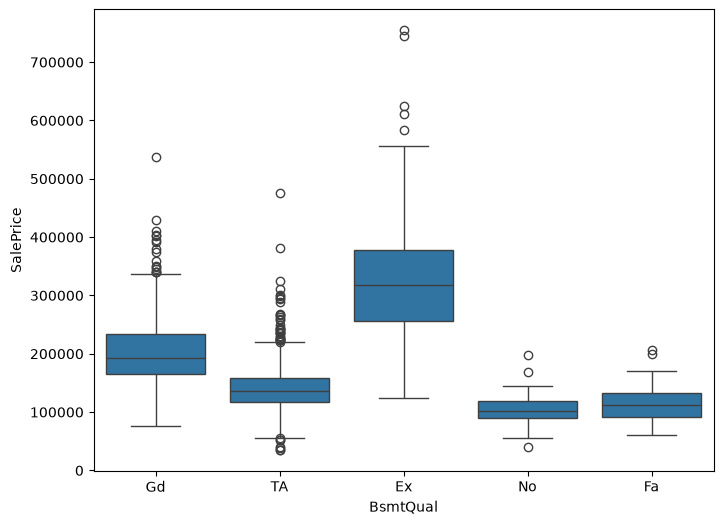


Feature : BsmtQual
----------------------------------------
F Statistic : 316.1486
P Value     : 0.000000
Critical F  : 2.3780

Decision:
✓ Reject H₀
There is a statistically significant difference in mean SalePrice among the categories.
       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
group1 group2   meandiff   p-adj     lower        upper     reject
------------------------------------------------------------------
    Ex     Fa -211349.0128    0.0 -241850.2583 -180847.7672   True
    Ex     Gd -124352.5624    0.0 -140151.1142 -108554.0106   True
    Ex     No -221388.1494    0.0 -251243.1428 -191533.1561   True
    Ex     TA -186281.2231    0.0 -202017.8741 -170544.5722   True
    Fa     Gd   86996.4504    0.0   59383.6589  114609.2419   True
    Fa     No  -10039.1367 0.9491  -47511.6952   27433.4218  False
    Fa     TA   25067.7896 0.0951   -2509.6322   52645.2115  False
    Gd     No  -97035.5871    0.0 -123932.8156  -70138.3586   True
    Gd     TA  -61928.66

In [67]:
df['BsmtQual'] = df['BsmtQual'].fillna("No")
categorical_missing_analysis(df=df,categorical_col='BsmtQual')

BsmtCond
TA    1311
Gd      65
Fa      45
No      37
Po       2
Name: count, dtype: int64


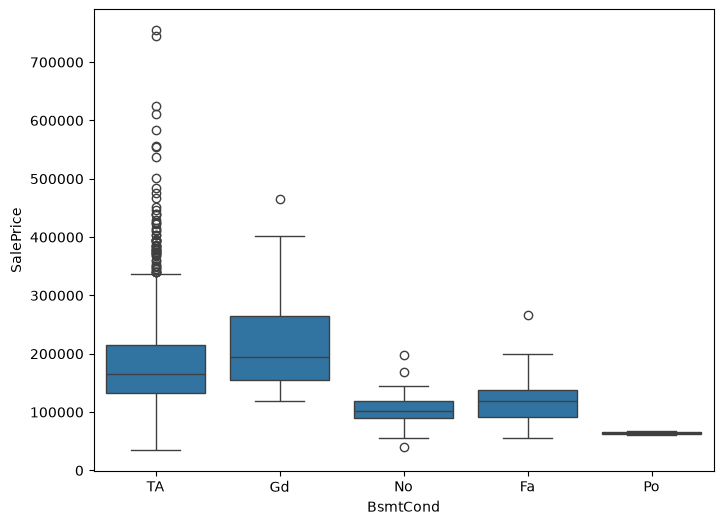


Feature : BsmtCond
----------------------------------------
F Statistic : 19.7081
P Value     : 0.000000
Critical F  : 2.3780

Decision:
✓ Reject H₀
There is a statistically significant difference in mean SalePrice among the categories.
       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
group1 group2   meandiff   p-adj     lower        upper    reject
-----------------------------------------------------------------
    Fa     Gd   91790.3744    0.0   50753.1013 132827.6474   True
    Fa     No  -16156.6414 0.8814  -63118.4587  30805.1758  False
    Fa     Po  -57809.5333 0.8403 -210732.5163  95113.4496  False
    Fa     TA   61823.0876    0.0   29740.6522   93905.523   True
    Gd     No -107947.0158    0.0 -151527.0566  -64366.975   True
    Gd     Po -149599.9077  0.056 -301518.4595   2318.6441  False
    Gd     TA  -29967.2868 0.0201  -56857.6259  -3076.9477   True
    No     Po  -41652.8919 0.9469 -195277.7626 111971.9788  False
    No     TA    77979.729    0.0   

In [68]:
df['BsmtCond'] = df['BsmtCond'].fillna("No")
categorical_missing_analysis(df=df,categorical_col='BsmtCond')

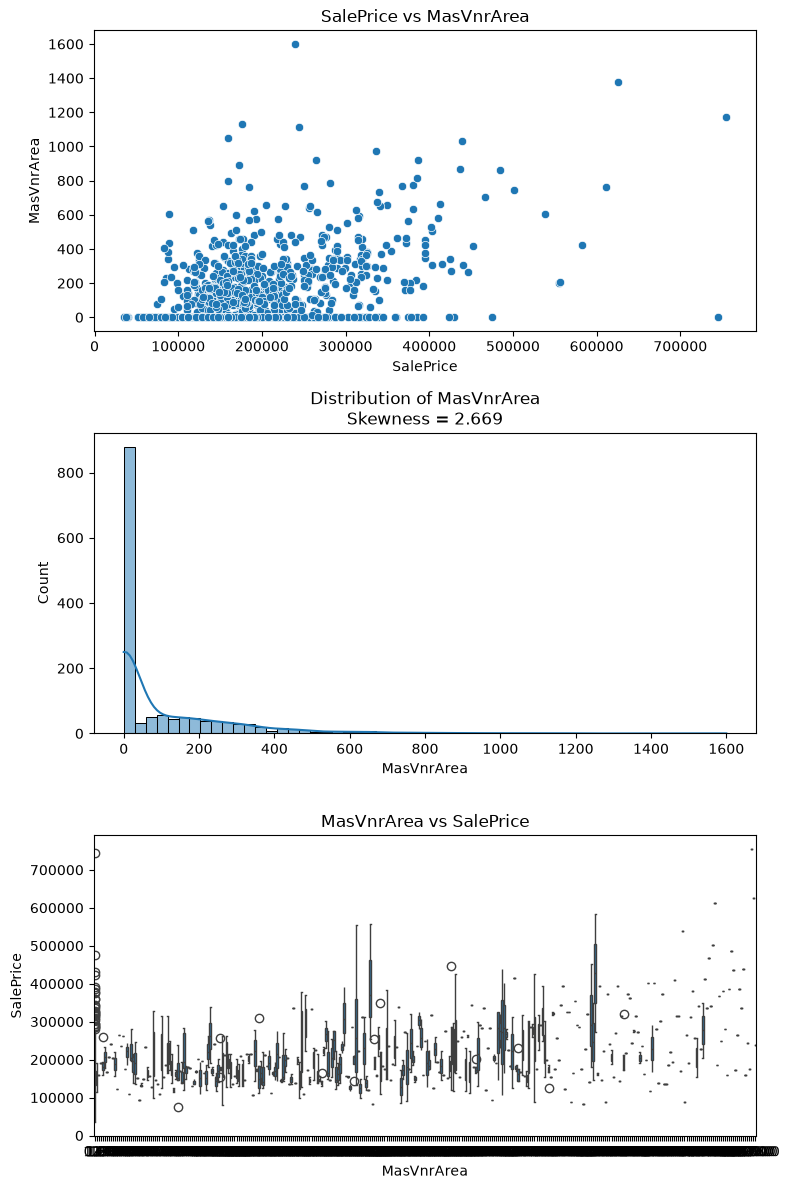

Column           : MasVnrArea
Missing Values   : 8
Missing Percent  : 0.55%
Skewness         : 2.669
Median           : 0.00
Mean             : 103.69


In [69]:
numerical_missing_analysis(num_col='MasVnrArea')

Electrical
SBrkr    1335
FuseA      94
FuseF      27
FuseP       3
Mix         1
Name: count, dtype: int64


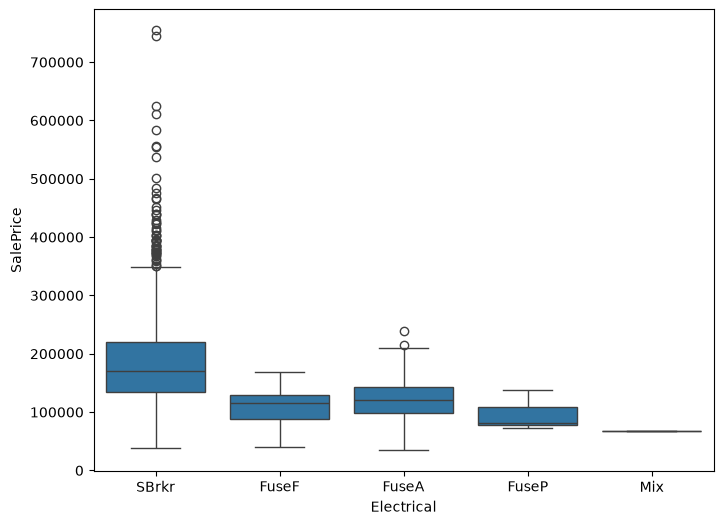


Feature : Electrical
----------------------------------------
F Statistic : 23.0744
P Value     : 0.000000
Critical F  : 2.3780

Decision:
✓ Reject H₀
There is a statistically significant difference in mean SalePrice among the categories.
      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
group1 group2   meandiff  p-adj     lower        upper    reject
----------------------------------------------------------------
 FuseA  FuseF -14521.4492 0.9106  -60525.2793   31482.381  False
 FuseA  FuseP -24863.5603  0.982 -148432.2461  98705.1256  False
 FuseA    Mix -55196.8936 0.9539  -267006.177 156612.3898  False
 FuseA  SBrkr  64613.7438    0.0   42130.5156  87096.9721   True
 FuseF  FuseP -10342.1111 0.9995 -138564.9042  117880.682  False
 FuseF    Mix -40675.4444 0.9856 -255233.2154 173882.3265  False
 FuseF  SBrkr   79135.193    0.0   38179.6061 120090.7799   True
 FuseP    Mix -30333.3333 0.9971 -273618.9778 212952.3111  False
 FuseP  SBrkr  89477.3041 0.2632  -32302.1187

In [73]:
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])
categorical_missing_analysis(df=df,categorical_col='Electrical')

BsmtExposure
No    991
Av    221
Gd    134
Mn    114
Name: count, dtype: int64


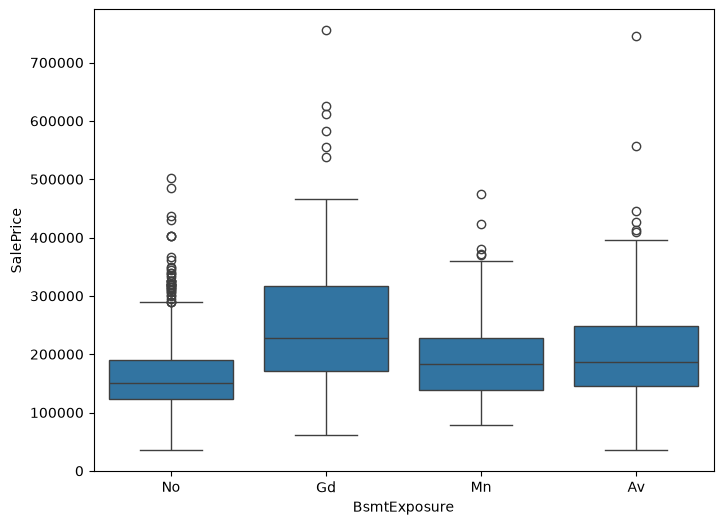


Feature : BsmtExposure
----------------------------------------
F Statistic : 76.5779
P Value     : 0.000000
Critical F  : 2.6110

Decision:
✓ Reject H₀
There is a statistically significant difference in mean SalePrice among the categories.
      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
group1 group2   meandiff  p-adj     lower        upper    reject
----------------------------------------------------------------
    Av     Gd  51046.3852    0.0   30233.9552  71858.8151   True
    Av     Mn -13853.7629 0.3645  -35773.2804   8065.7545  False
    Av     No -43204.1726    0.0  -57345.0219 -29063.3233   True
    Gd     Mn -64900.1481    0.0  -89120.3725 -40679.9236   True
    Gd     No -94250.5577    0.0 -111746.7758 -76754.3397   True
    Mn     No -29350.4097 0.0004  -48150.0281 -10550.7913   True
----------------------------------------------------------------


In [88]:
df['BsmtExposure'] = df['BsmtExposure'].fillna("No")
categorical_missing_analysis(df=df,categorical_col='BsmtExposure')

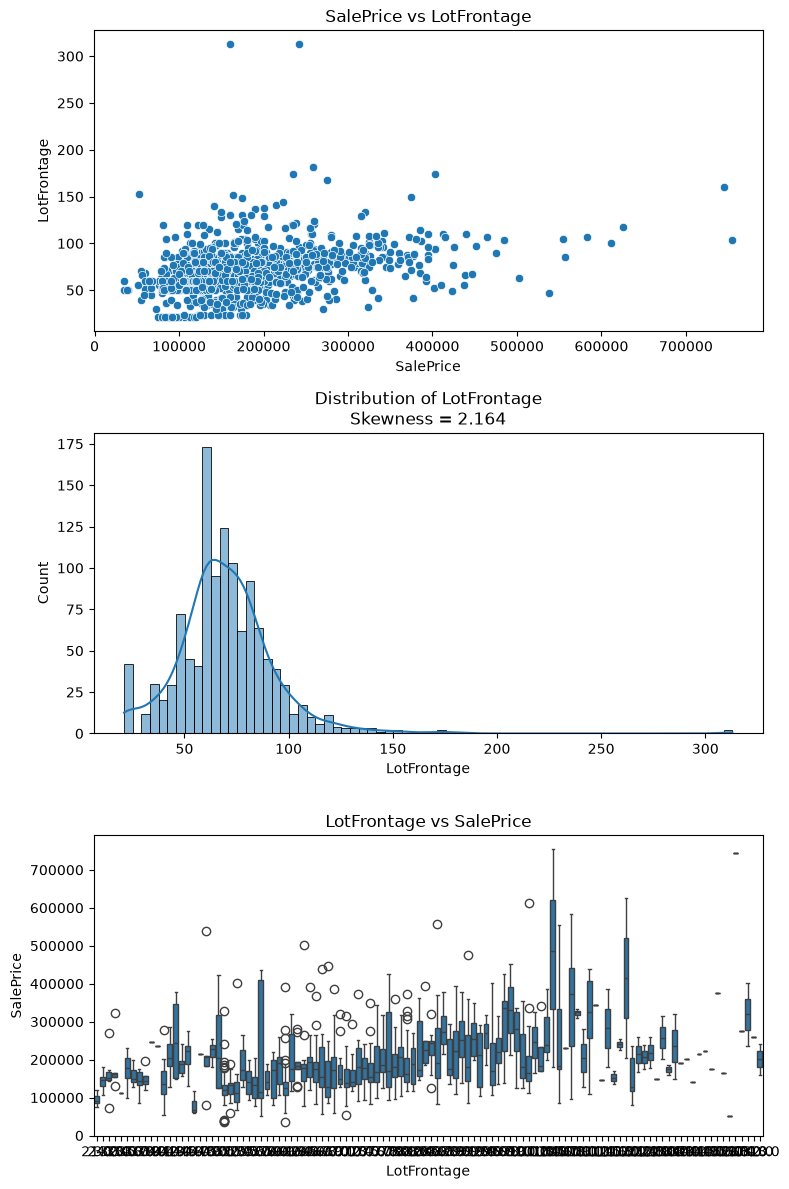

Column           : LotFrontage
Missing Values   : 259
Missing Percent  : 17.74%
Skewness         : 2.164
Median           : 69.00
Mean             : 70.05


In [74]:
numerical_missing_analysis(num_col='LotFrontage')

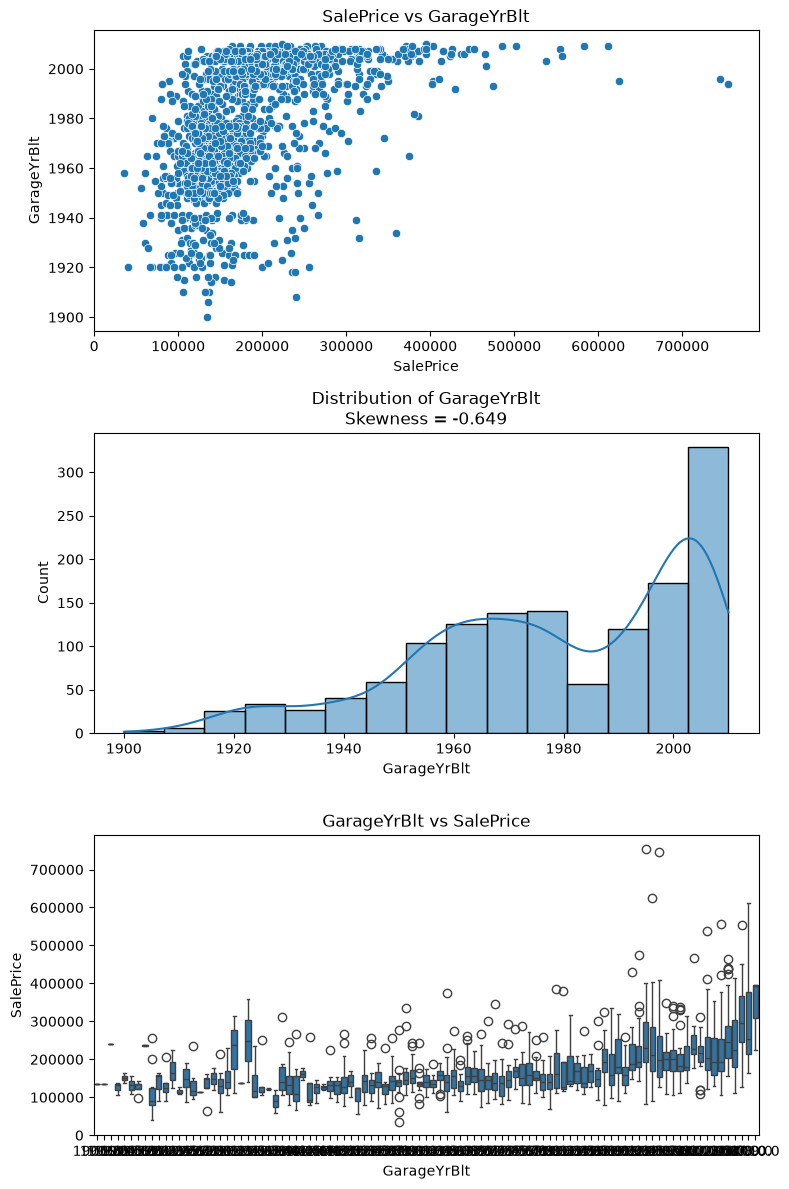

Column           : GarageYrBlt
Missing Values   : 81
Missing Percent  : 5.55%
Skewness         : -0.649
Median           : 1980.00
Mean             : 1978.51


In [75]:
numerical_missing_analysis(num_col='GarageYrBlt')

In [77]:
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)

In [78]:
df["LotFrontage"] = df["LotFrontage"].fillna(0)

In [79]:
df["GarageYrBlt"] = df["GarageYrBlt"].fillna(0)

In [90]:
df.to_csv("df_no_nan.csv", index=False)

WE WILL CONDUCT HYPOTHESIS TEST FOR OVERALL QUAL TO CHECK WHETEHR HIGHER OVERALLQUAL REALLY HEPLS 
INCREASE IN PRICES

In [91]:
low_qual = df[df['OverallQual']<7]['SalePrice']
high_qual = df[df['OverallQual']>=7]['SalePrice']

NULL HYPOTHESIS:BOTH GROUPS HAVE SIMILAR SALE PRICE(MEAN_HIGH = MEAN_LOW) ALTERNATIVE HYPOTHESIS:BOTH GROUPS HAVE DIFFERENT AVG SALE PRICE(MEAN_HIGH != MEAN_LOW)

IF WE GET P_VALUE < 0.05,THEN WE REJECT NULL HYPOTHESIS AND CONCLUDE THAT HGIHER QUAL HOUSES ARE EXPENSIVE

In [93]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(
    high_qual,
    low_qual,
    equal_var=False)

alpha = 0.05
mean_low = low_qual.mean()
mean_high = high_qual.mean()
mean_diff = abs(mean_high-mean_low)

print(f"T Statistic : {t_stat:.4f}")
print(f"P Value : {p_value}")
print(f"Aplha : {alpha}")
print(f"Mean Difference : {mean_diff}")
print("\n")
if p_value < alpha:
    print("We Can Reject Null Hypothesis")
else:
    print("We Fail To Reject Null Hypothesis")

T Statistic : 28.2141
P Value : 1.8445147442018962e-116
Aplha : 0.05
Mean Difference : 108000.62266295301


We Can Reject Null Hypothesis


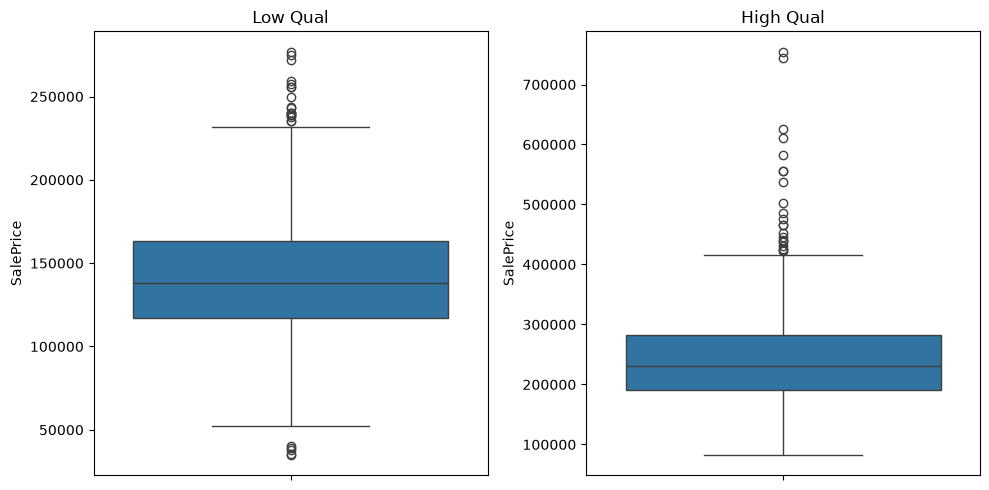

In [94]:
fig,axes = plt.subplots(1,2,figsize=(10,5))

sns.boxplot(y=low_qual,ax=axes[0])
axes[0].set_title("Low Qual")

sns.boxplot(y=high_qual,ax=axes[1])
axes[1].set_title("High Qual")

plt.tight_layout()
plt.show()

In [95]:
population = low_qual 
sample = population.sample(100)
bootstrap_sample_means = []

for i in range(len(sample)):
    bootstrap_sample = sample.sample(n=100,replace=True)
    bootstrap_sample_means.append(bootstrap_sample.mean())

arr = np.array(bootstrap_sample_means)
sorted_arr = np.sort(arr) 

lower = np.quantile(sorted_arr,2.5/100)
upper = np.quantile(sorted_arr,97.5/100)

ci = (f'{lower:.3f} : {upper:.3f}')
print(f'95% Confidence Interval Range For Low Qual House Price : {ci}')
print(f'Mean House Price For Low Qual : {population.mean()}')

95% Confidence Interval Range For Low Qual House Price : 129951.287 : 143602.700
Mean House Price For Low Qual : 140383.97587719298


In [96]:
population = high_qual 
sample = population.sample(100)
bootstrap_sample_means = []

for i in range(len(sample)):
    bootstrap_sample = sample.sample(n=100,replace=True)
    bootstrap_sample_means.append(bootstrap_sample.mean())

arr = np.array(bootstrap_sample_means)
sorted_arr = np.sort(arr) 

lower = np.quantile(sorted_arr,2.5/100)
upper = np.quantile(sorted_arr,97.5/100)

ci = (f'{lower:.3f} : {upper:.3f}')
print(f'95% Confidence Interval Range For High Qual House Price : {ci}')
print(f'Mean House Price For High Qual : {population.mean()}')

95% Confidence Interval Range For High Qual House Price : 240248.163 : 271360.310
Mean House Price For High Qual : 248384.598540146


A Welch's two-sample t-test yielded a t-statistic of 28.21 and a p-value of 1.84 × 10⁻¹¹⁶, providing overwhelming evidence to reject the null hypothesis at α = 0.05. The 95% confidence interval for the mean sale price of low-quality houses is $132,552–$147,675, while that of high-quality houses is $227,378–$254,855. These results indicate that houses with higher overall quality have significantly higher average selling prices.

95% Confidence Interval Range For Low Qual House Price : 129951.287 : 143602.700
Mean House Price For Low Qual : 140383.97587719298

95% Confidence Interval Range For High Qual House Price : 240248.163 : 271360.310
Mean House Price For High Qual : 248384.598540146

A Welch's two-sample t-test yielded a t-statistic of 28.21 and a p-value of 1.84 × 10⁻¹¹⁶, providing overwhelming evidence to reject the null hypothesis at α = 0.05. The 95% confidence interval for the mean sale price of low-quality houses is $132,552–$147,675, while that of high-quality houses is $227,378–$254,855. These results indicate that houses with higher overall quality have significantly higher average selling prices.